# Crop Recommendation — Mineração de Dados
**Dataset:** [Crop Recommendation Dataset](https://www.kaggle.com/datasets/atharvaingle/crop-recommendation-dataset)

**Objetivo:** Prever a cultura agrícola mais adequada com base em atributos do solo e clima.

## 1. Instalação e Importação de Bibliotecas

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score
)
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')
print('Bibliotecas carregadas com sucesso!')

Bibliotecas carregadas com sucesso!


## 2. Carregamento do Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Data Mining/archive (1)/Crop_recommendation.csv')

print('Dataset carregado com sucesso! Primeiras 5 linhas:')
print(df.head())

Mounted at /content/drive
Dataset carregado com sucesso! Primeiras 5 linhas:
    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice


## 3. Análise Exploratória dos Dados (EDA)

In [ ]:
print('=== Informações gerais ===')
df.info()
print('\n=== Estatísticas descritivas ===')
df.describe()

=== Informações gerais ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB

=== Estatísticas descritivas ===


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [ ]:
print('Classes (culturas):', df['label'].nunique())
print(df['label'].value_counts())

Classes (culturas): 22
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


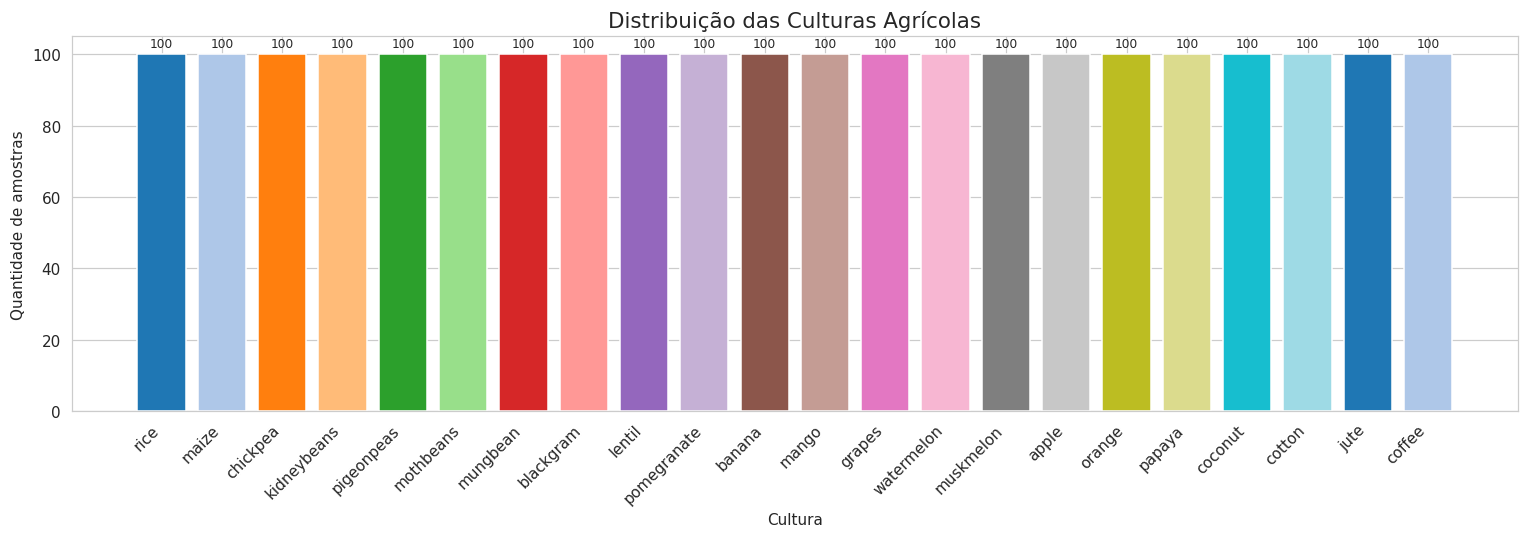

In [ ]:
# Distribuição das classes
plt.figure(figsize=(14, 5))
counts = df['label'].value_counts()
bars = plt.bar(counts.index, counts.values, color=sns.color_palette('tab20', len(counts)))
plt.xticks(rotation=45, ha='right')
plt.title('Distribuição das Culturas Agrícolas', fontsize=14)
plt.xlabel('Cultura')
plt.ylabel('Quantidade de amostras')
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(val),
             ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('class_distribution.png', bbox_inches='tight')
plt.show()

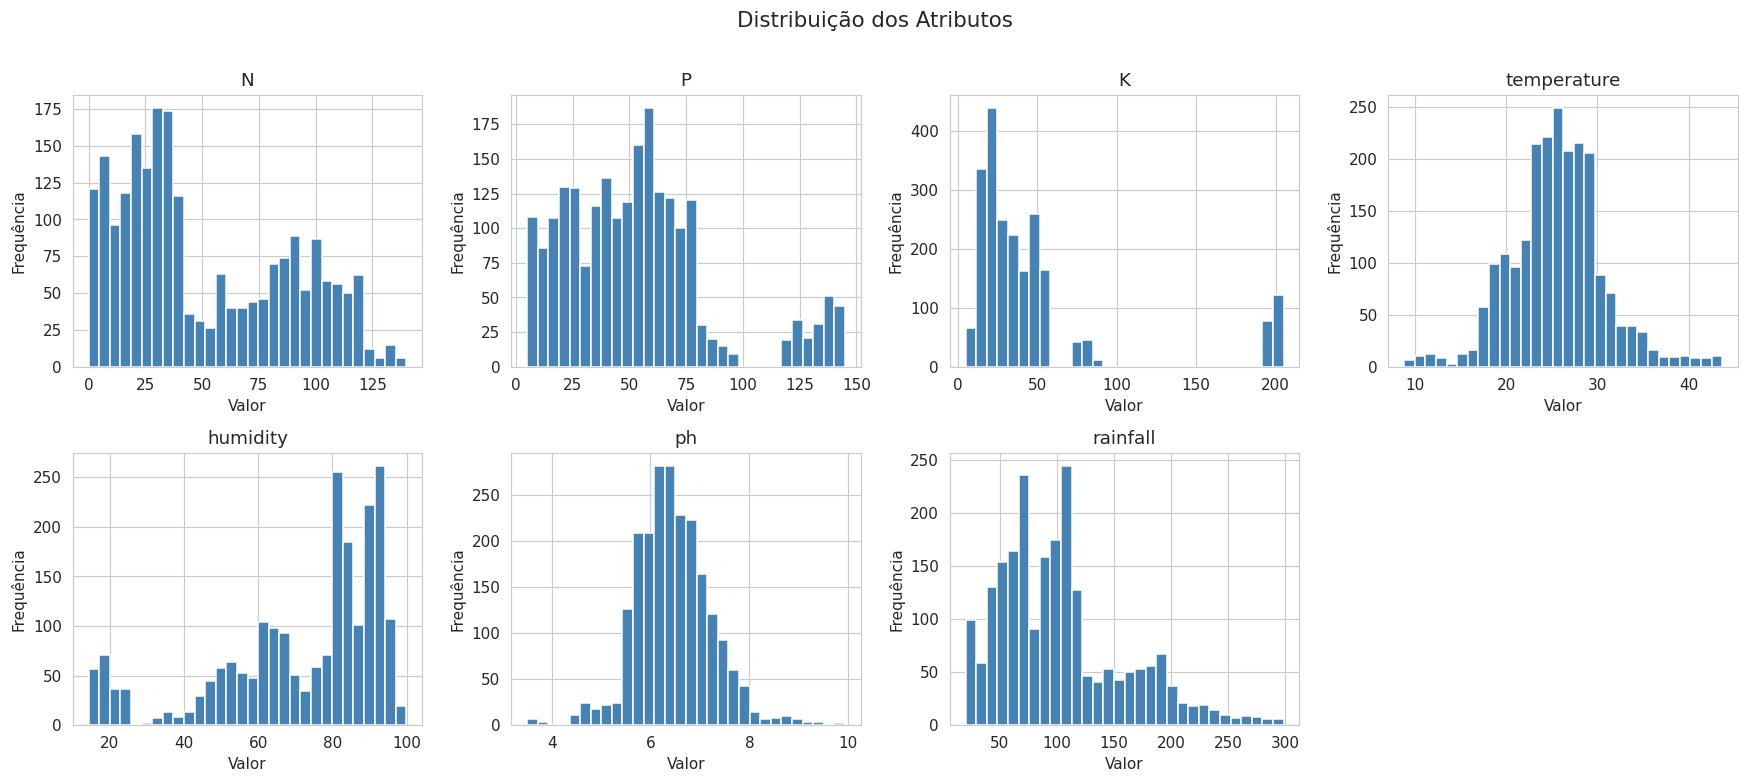

In [ ]:
# Distribuição dos atributos numéricos
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(features):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frequência')
axes[-1].set_visible(False)
plt.suptitle('Distribuição dos Atributos', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', bbox_inches='tight')
plt.show()

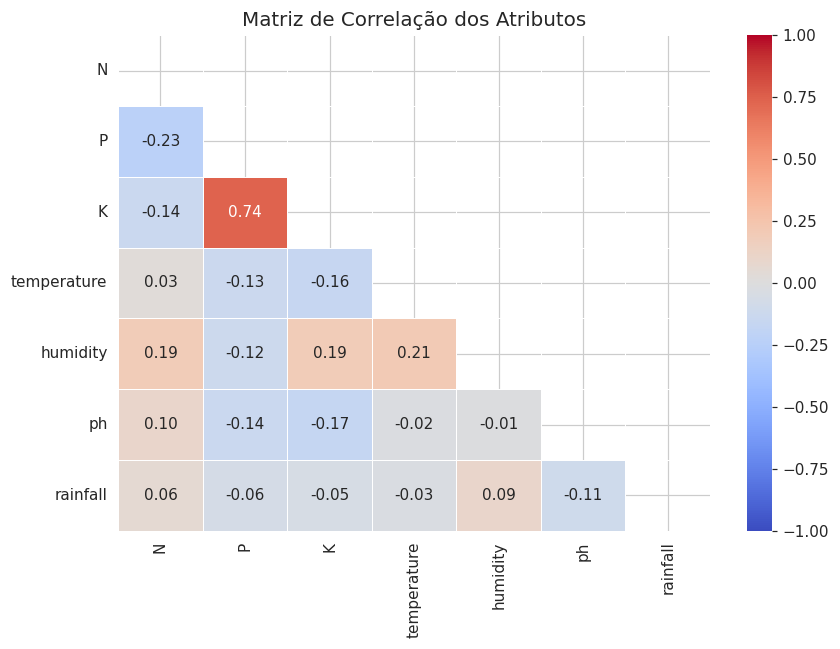

In [ ]:
# Matriz de correlação
plt.figure(figsize=(8, 6))
corr = df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', mask=mask,
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de Correlação dos Atributos', fontsize=13)
plt.tight_layout()
plt.savefig('correlation_matrix.png', bbox_inches='tight')
plt.show()

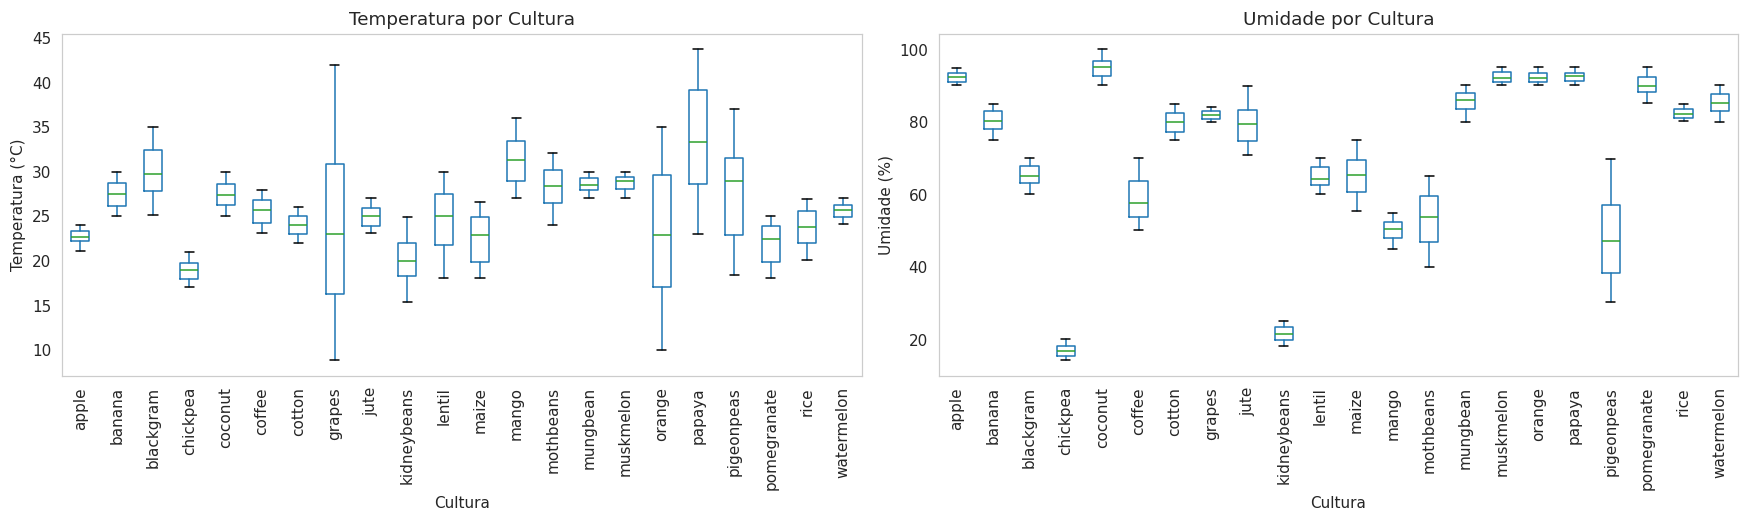

In [ ]:
# Boxplots por cultura (temperatura e umidade)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
df.boxplot(column='temperature', by='label', ax=axes[0], rot=90, grid=False)
axes[0].set_title('Temperatura por Cultura')
axes[0].set_xlabel('Cultura')
axes[0].set_ylabel('Temperatura (°C)')
plt.sca(axes[0]); plt.title('Temperatura por Cultura')

df.boxplot(column='humidity', by='label', ax=axes[1], rot=90, grid=False)
axes[1].set_title('Umidade por Cultura')
axes[1].set_xlabel('Cultura')
axes[1].set_ylabel('Umidade (%)')
plt.sca(axes[1]); plt.title('Umidade por Cultura')

plt.suptitle('')
plt.tight_layout()
plt.savefig('boxplots.png', bbox_inches='tight')
plt.show()

## 4. Pré-processamento

In [ ]:
# 4.1 Valores ausentes
print('=== Valores ausentes por coluna ===')
missing = df.isnull().sum()
print(missing)
print(f'\nTotal de missing values: {missing.sum()}')

=== Valores ausentes por coluna ===
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Total de missing values: 0


In [ ]:
# 4.2 Detecção de outliers com IQR
print('=== Detecção de outliers (IQR) ===')
outlier_summary = {}
for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary[col] = {'Q1': round(Q1,2), 'Q3': round(Q3,2),
                             'Limite Inf': round(lower,2), 'Limite Sup': round(upper,2),
                             'Outliers': n_out}
outlier_df = pd.DataFrame(outlier_summary).T
print(outlier_df)

=== Detecção de outliers (IQR) ===
                Q1      Q3  Limite Inf  Limite Sup  Outliers
N            21.00   84.25      -73.88      179.12       0.0
P            28.00   68.00      -32.00      128.00     138.0
K            20.00   49.00      -23.50       92.50     200.0
temperature  22.77   28.56       14.08       37.25      86.0
humidity     60.26   89.95       15.73      134.48      30.0
ph            5.97    6.92        4.54        8.35      57.0
rainfall     64.55  124.27      -25.02      213.84     100.0


In [ ]:
# 4.3 Tratamento de outliers: clipping nos limites IQR
df_clean = df.copy()
for col in features:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_clean[col] = df_clean[col].clip(lower, upper)

print(f'Amostras antes: {len(df)} | Amostras após (clipping): {len(df_clean)}')

Amostras antes: 2200 | Amostras após (clipping): 2200


In [ ]:
# 4.4 Codificação do rótulo
le = LabelEncoder()
df_clean['label_enc'] = le.fit_transform(df_clean['label'])
print('Classes codificadas:')
for i, c in enumerate(le.classes_):
    print(f'  {i:2d} -> {c}')

Classes codificadas:
   0 -> apple
   1 -> banana
   2 -> blackgram
   3 -> chickpea
   4 -> coconut
   5 -> coffee
   6 -> cotton
   7 -> grapes
   8 -> jute
   9 -> kidneybeans
  10 -> lentil
  11 -> maize
  12 -> mango
  13 -> mothbeans
  14 -> mungbean
  15 -> muskmelon
  16 -> orange
  17 -> papaya
  18 -> pigeonpeas
  19 -> pomegranate
  20 -> rice
  21 -> watermelon


In [ ]:
# 4.5 Separação X / y e divisão treino-teste
X = df_clean[features].values
y = df_clean['label_enc'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Treino: {X_train.shape} | Teste: {X_test.shape}')

Treino: (1760, 7) | Teste: (440, 7)


In [ ]:
# 4.6 Escalonamento (StandardScaler)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('Média (treino escalado):', X_train_sc.mean(axis=0).round(4))
print('Desvio (treino escalado):', X_train_sc.std(axis=0).round(4))

Média (treino escalado): [-0.  0. -0. -0. -0. -0. -0.]
Desvio (treino escalado): [1. 1. 1. 1. 1. 1. 1.]


## 5. Classificação

### 5.1 Árvore de Decisão

In [ ]:
dt = DecisionTreeClassifier(max_depth=8, random_state=42)
dt.fit(X_train_sc, y_train)
y_pred_dt = dt.predict(X_test_sc)

acc_dt = accuracy_score(y_test, y_pred_dt)
f1_dt  = f1_score(y_test, y_pred_dt, average='weighted')
print(f'Decision Tree  | Acurácia: {acc_dt:.4f} | F1-weighted: {f1_dt:.4f}')

Decision Tree  | Acurácia: 0.8705 | F1-weighted: 0.8521


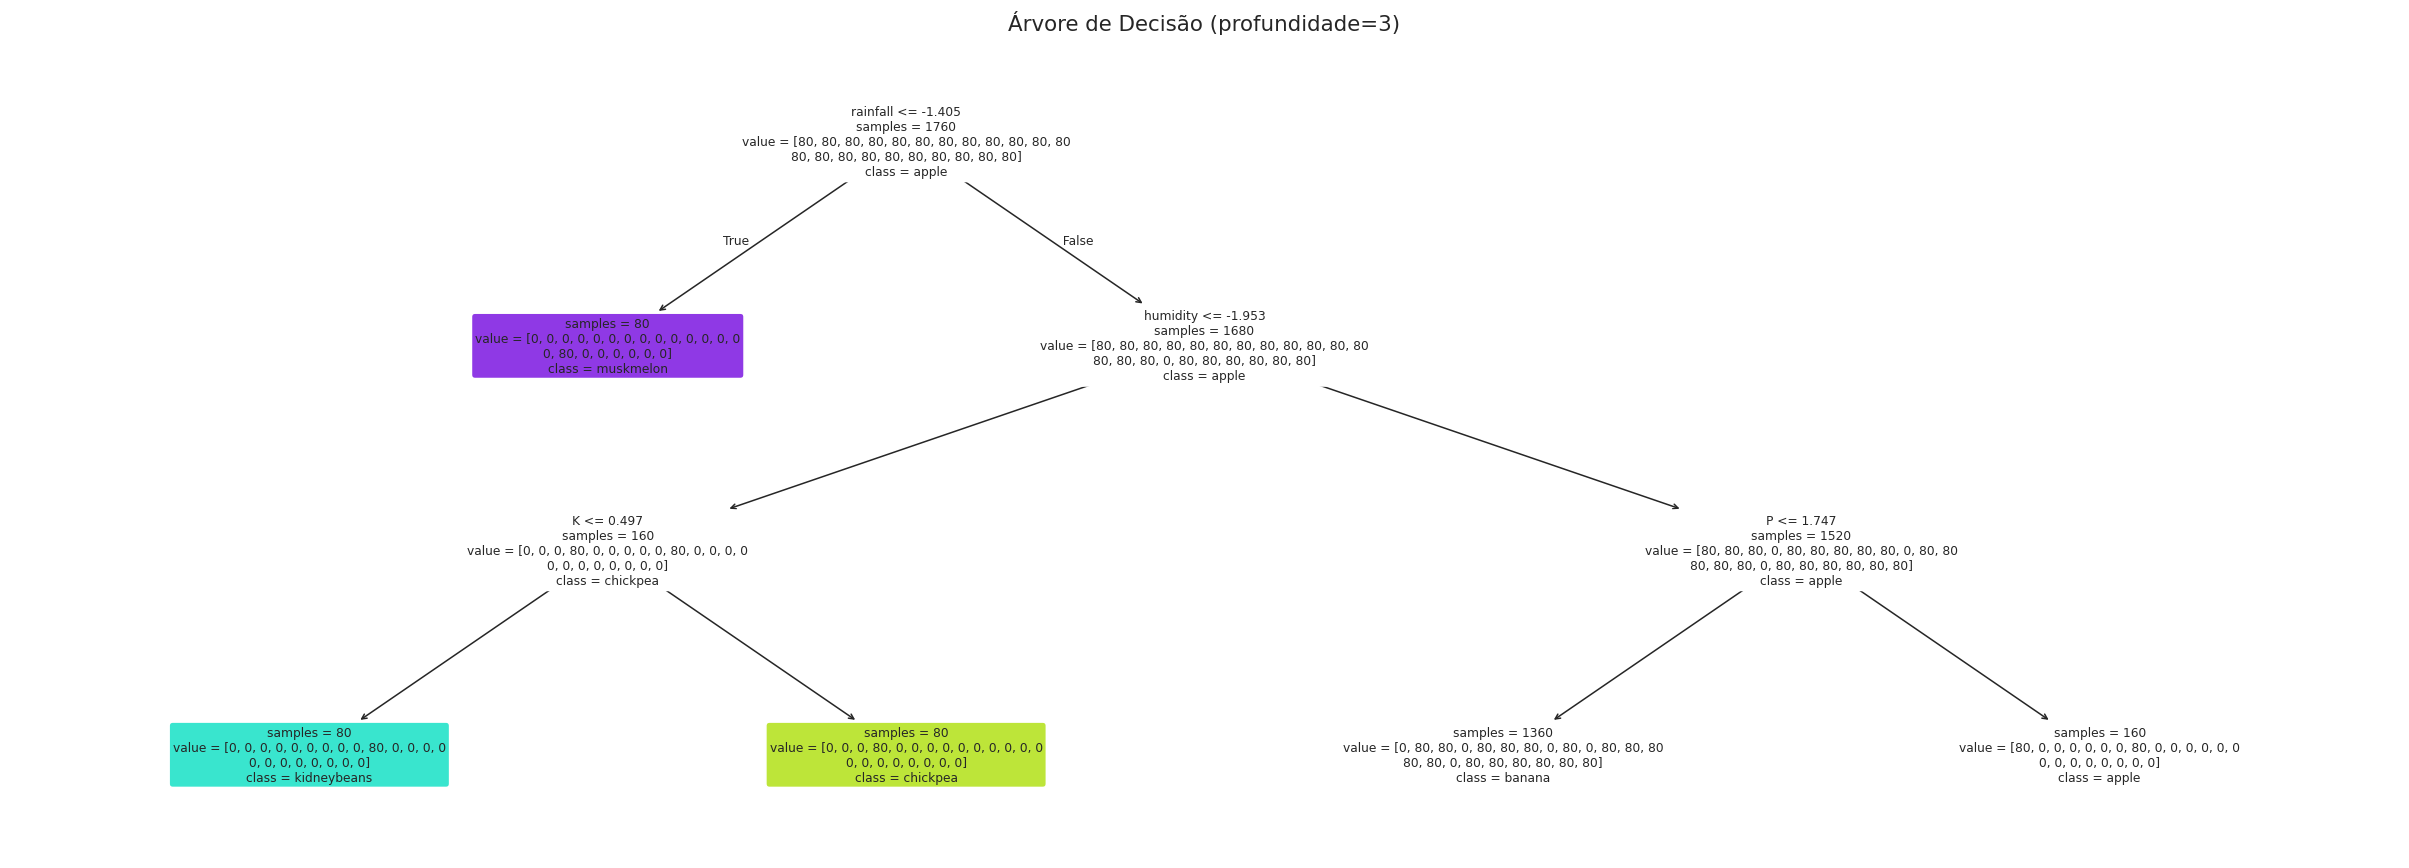

In [ ]:
# Visualização da árvore (profundidade limitada para legibilidade)
dt_viz = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_viz.fit(X_train_sc, y_train)

plt.figure(figsize=(22, 8))
plot_tree(dt_viz, feature_names=features, class_names=le.classes_,
          filled=True, rounded=True, fontsize=8, impurity=False)
plt.title('Árvore de Decisão (profundidade=3)', fontsize=14)
plt.tight_layout()
plt.savefig('decision_tree.png', bbox_inches='tight')
plt.show()

### 5.2 Random Forest

In [ ]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train_sc, y_train)
y_pred_rf = rf.predict(X_test_sc)

acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf  = f1_score(y_test, y_pred_rf, average='weighted')
print(f'Random Forest  | Acurácia: {acc_rf:.4f} | F1-weighted: {f1_rf:.4f}')

Random Forest  | Acurácia: 0.9932 | F1-weighted: 0.9932


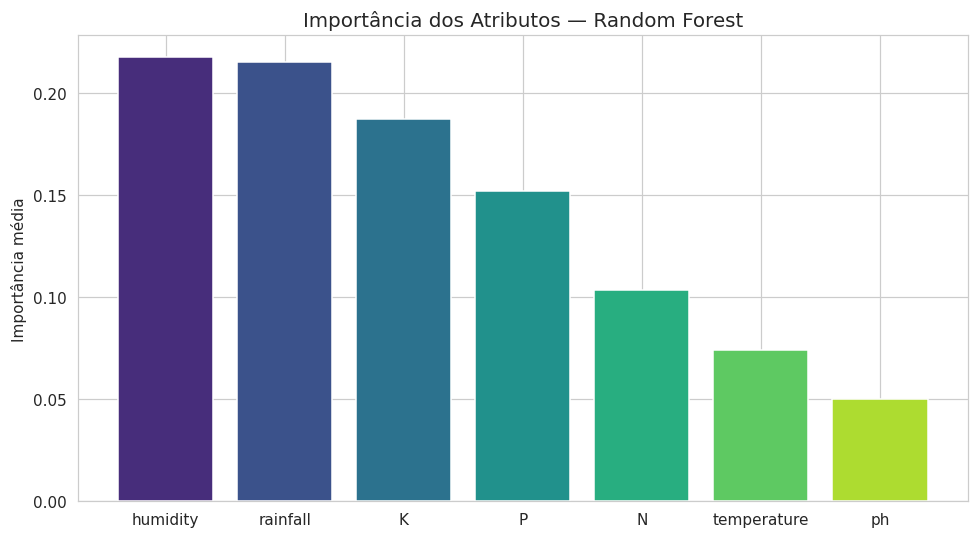

In [ ]:
# Importância dos atributos
importances = rf.feature_importances_
idx = np.argsort(importances)[::-1]

plt.figure(figsize=(9, 5))
plt.bar(range(len(features)), importances[idx], color=sns.color_palette('viridis', len(features)))
plt.xticks(range(len(features)), [features[i] for i in idx])
plt.title('Importância dos Atributos — Random Forest', fontsize=13)
plt.ylabel('Importância média')
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

### 5.3 K-Nearest Neighbors

Melhor k: 3 | CV Acurácia: 0.9739


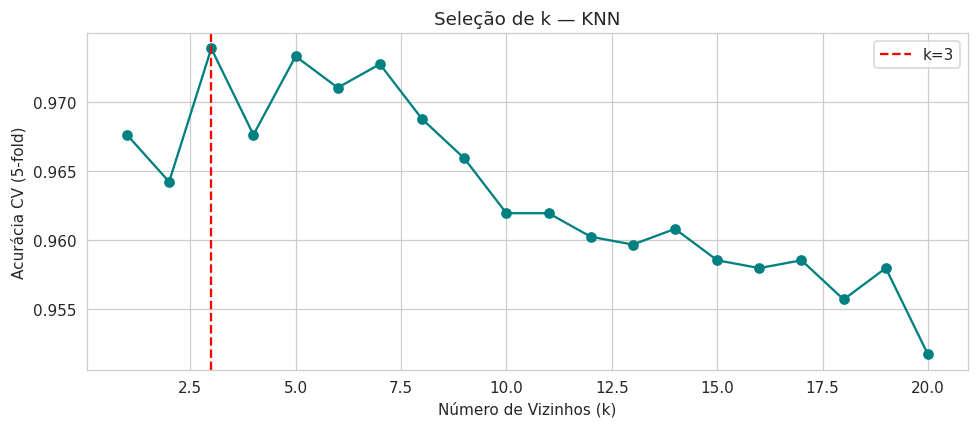

In [ ]:
# Escolha do melhor k via validação cruzada
k_range = range(1, 21)
cv_scores = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_sc, y_train, cv=skf, scoring='accuracy')
    cv_scores.append(scores.mean())

best_k = k_range[np.argmax(cv_scores)]
print(f'Melhor k: {best_k} | CV Acurácia: {max(cv_scores):.4f}')

plt.figure(figsize=(9, 4))
plt.plot(list(k_range), cv_scores, marker='o', color='teal')
plt.axvline(best_k, linestyle='--', color='red', label=f'k={best_k}')
plt.xlabel('Número de Vizinhos (k)')
plt.ylabel('Acurácia CV (5-fold)')
plt.title('Seleção de k — KNN')
plt.legend()
plt.tight_layout()
plt.savefig('knn_k_selection.png', bbox_inches='tight')
plt.show()

In [ ]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_sc, y_train)
y_pred_knn = knn.predict(X_test_sc)

acc_knn = accuracy_score(y_test, y_pred_knn)
f1_knn  = f1_score(y_test, y_pred_knn, average='weighted')
print(f'KNN (k={best_k})        | Acurácia: {acc_knn:.4f} | F1-weighted: {f1_knn:.4f}')

KNN (k=3)        | Acurácia: 0.9818 | F1-weighted: 0.9817


## 6. Avaliação dos Modelos

               Acurácia  Precisão (W)  Recall (W)  F1 (W)
Modelo                                                   
Decision Tree    0.8705        0.8573      0.8705  0.8521
Random Forest    0.9932        0.9935      0.9932  0.9932
KNN (k=3)        0.9818        0.9830      0.9818  0.9817


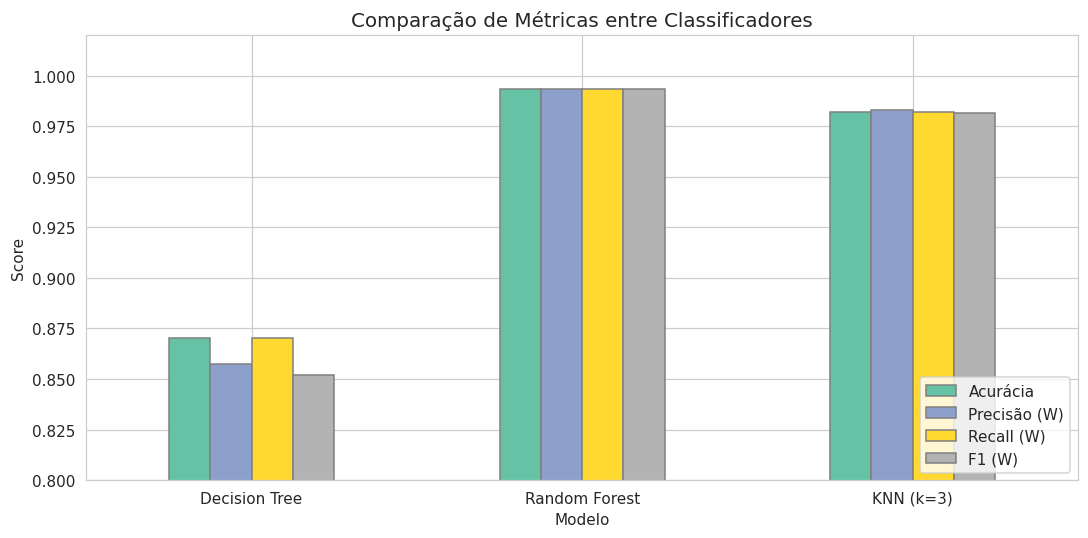

In [ ]:
# Resumo comparativo
results = pd.DataFrame({
    'Modelo': ['Decision Tree', 'Random Forest', f'KNN (k={best_k})'],
    'Acurácia': [acc_dt, acc_rf, acc_knn],
    'Precisão (W)': [
        precision_score(y_test, y_pred_dt, average='weighted'),
        precision_score(y_test, y_pred_rf, average='weighted'),
        precision_score(y_test, y_pred_knn, average='weighted'),
    ],
    'Recall (W)': [
        recall_score(y_test, y_pred_dt, average='weighted'),
        recall_score(y_test, y_pred_rf, average='weighted'),
        recall_score(y_test, y_pred_knn, average='weighted'),
    ],
    'F1 (W)': [f1_dt, f1_rf, f1_knn],
})
results = results.set_index('Modelo').round(4)
print(results)

# Gráfico de barras comparativo
ax = results.plot(kind='bar', figsize=(10, 5), colormap='Set2', edgecolor='grey')
plt.title('Comparação de Métricas entre Classificadores', fontsize=13)
plt.ylabel('Score')
plt.ylim(0.8, 1.02)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('metrics_comparison.png', bbox_inches='tight')
plt.show()

In [ ]:
# Relatório detalhado do melhor modelo (Random Forest)
print('=== Relatório de Classificação — Random Forest ===')
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

=== Relatório de Classificação — Random Forest ===
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.95      1.00      0.98        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1

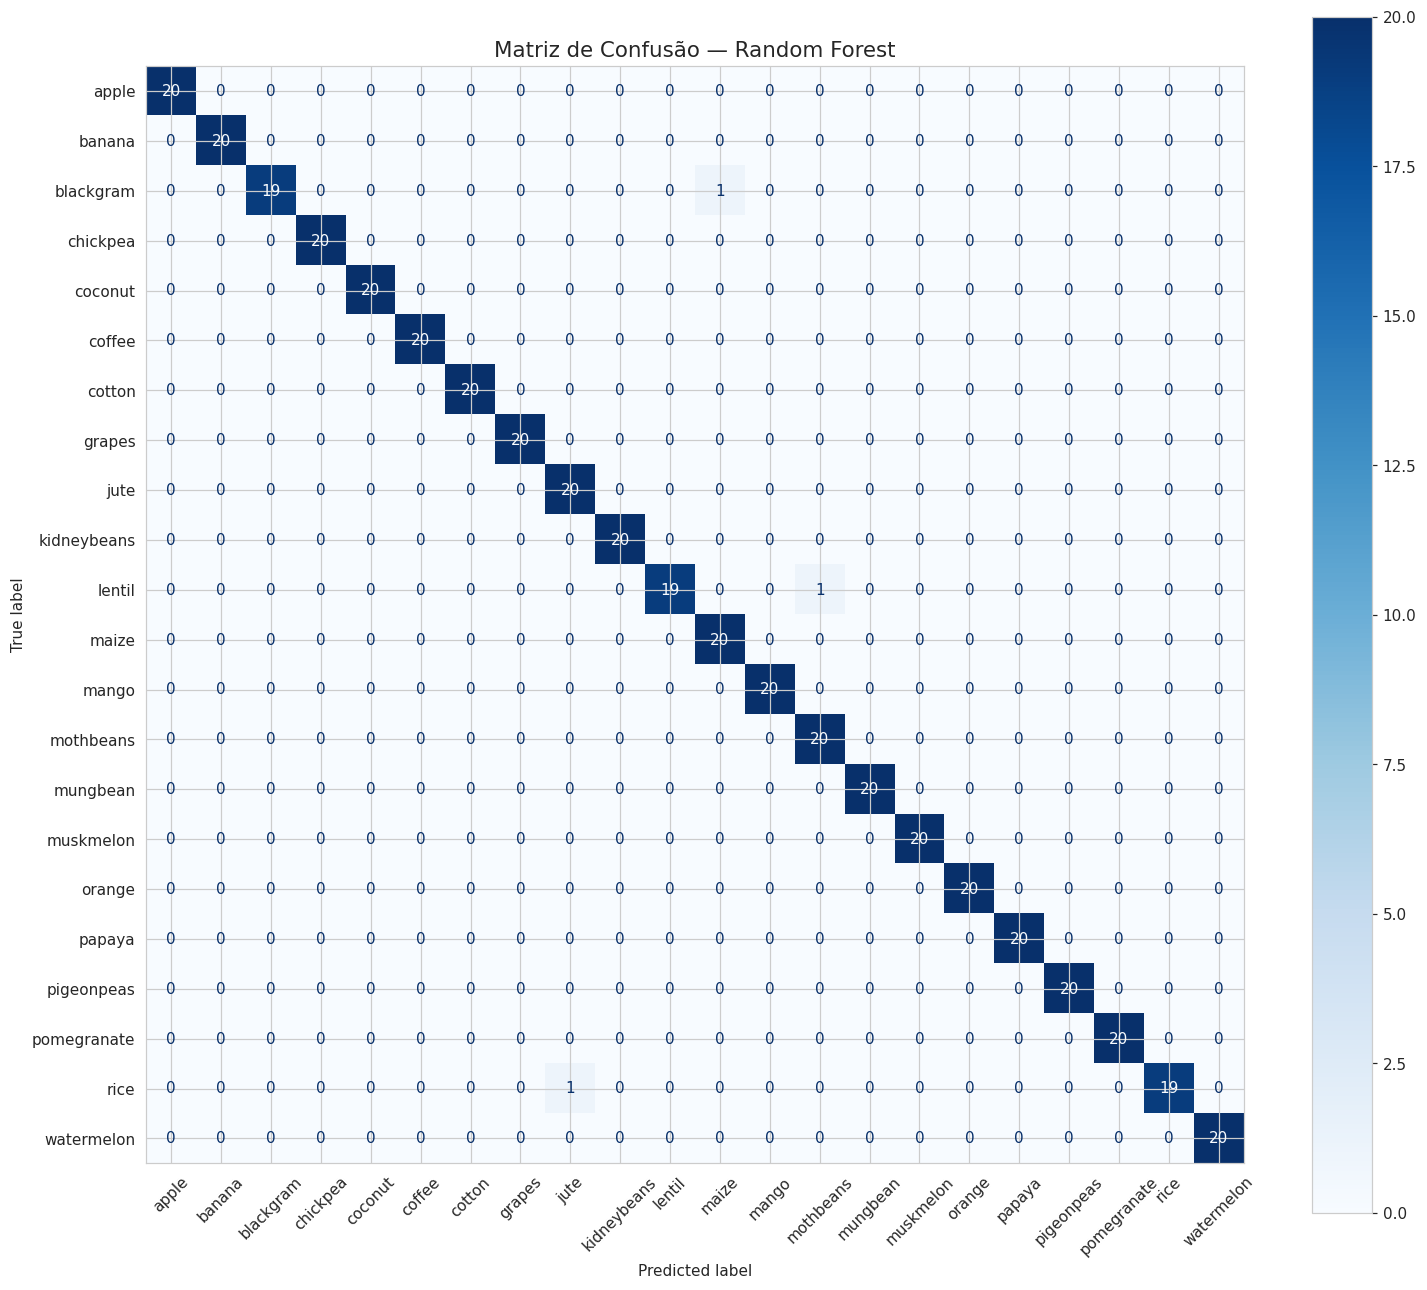

In [ ]:
# Matriz de Confusão — Random Forest
fig, ax = plt.subplots(figsize=(14, 12))
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=True, xticks_rotation=45)
ax.set_title('Matriz de Confusão — Random Forest', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrix_rf.png', bbox_inches='tight')
plt.show()

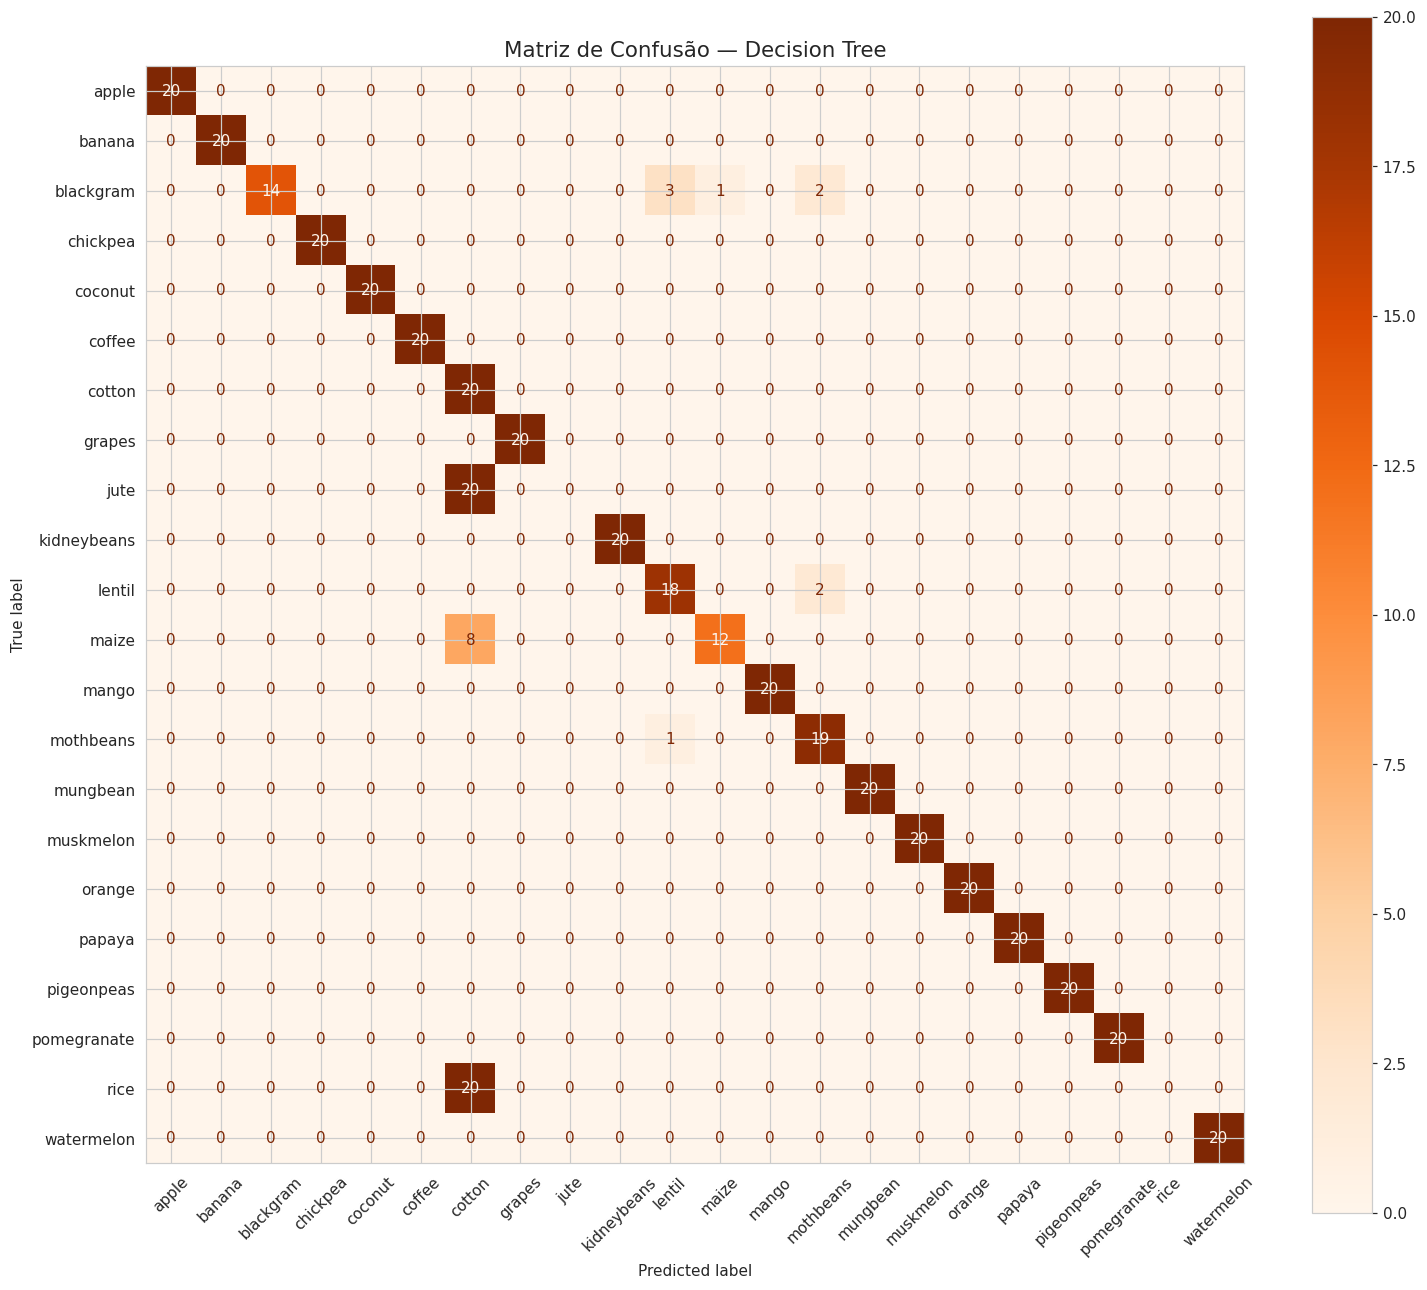

In [ ]:
# Matriz de Confusão — Decision Tree
fig, ax = plt.subplots(figsize=(14, 12))
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=le.classes_)
disp_dt.plot(ax=ax, cmap='Oranges', colorbar=True, xticks_rotation=45)
ax.set_title('Matriz de Confusão — Decision Tree', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrix_dt.png', bbox_inches='tight')
plt.show()

## 7. Superfície de Decisão (via PCA 2D)

In [ ]:
# Redução para 2 componentes para visualização
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_sc)
X_test_pca  = pca.transform(X_test_sc)

print(f'Variância explicada: PC1={pca.explained_variance_ratio_[0]:.2%}, '
      f'PC2={pca.explained_variance_ratio_[1]:.2%} '
      f'(total={sum(pca.explained_variance_ratio_):.2%})')

Variância explicada: PC1=24.55%, PC2=18.44% (total=42.99%)


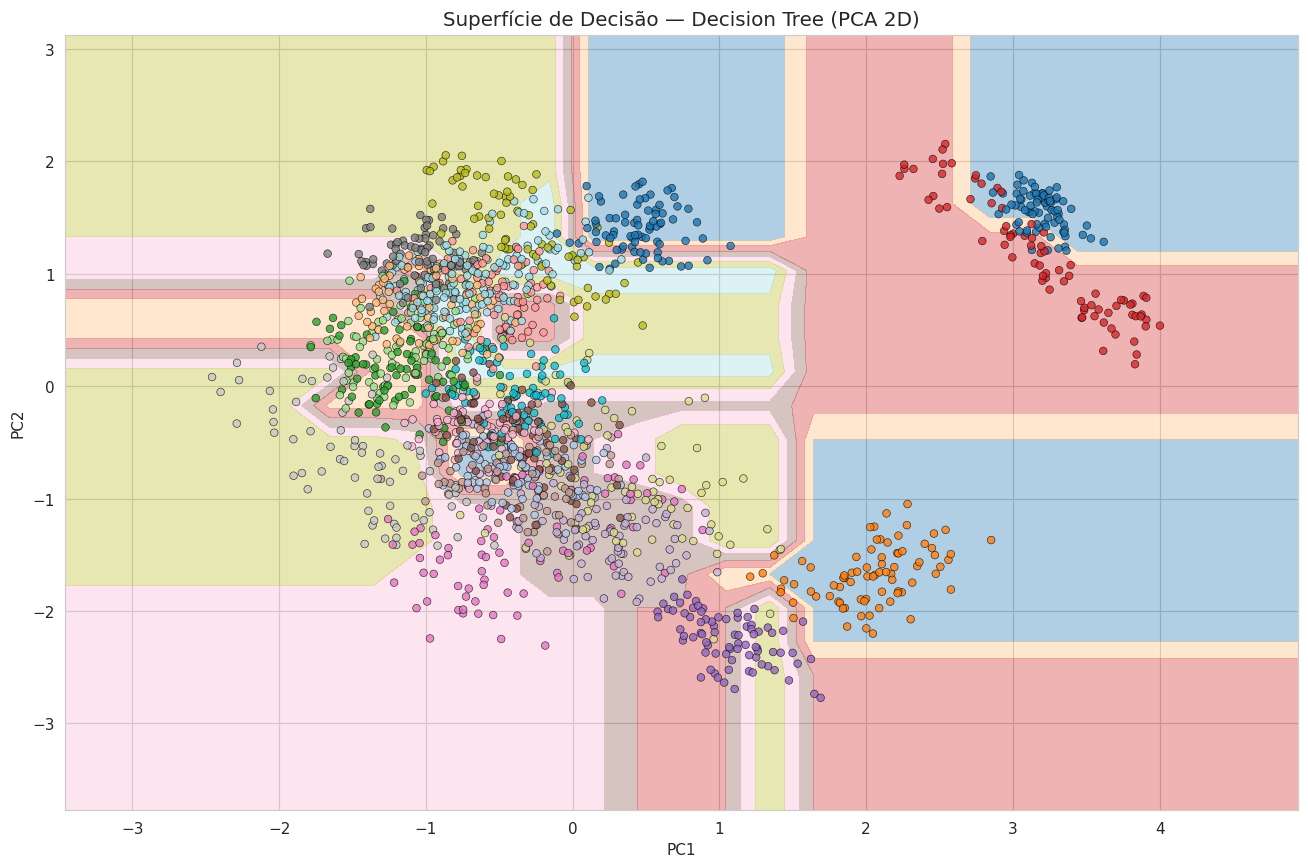

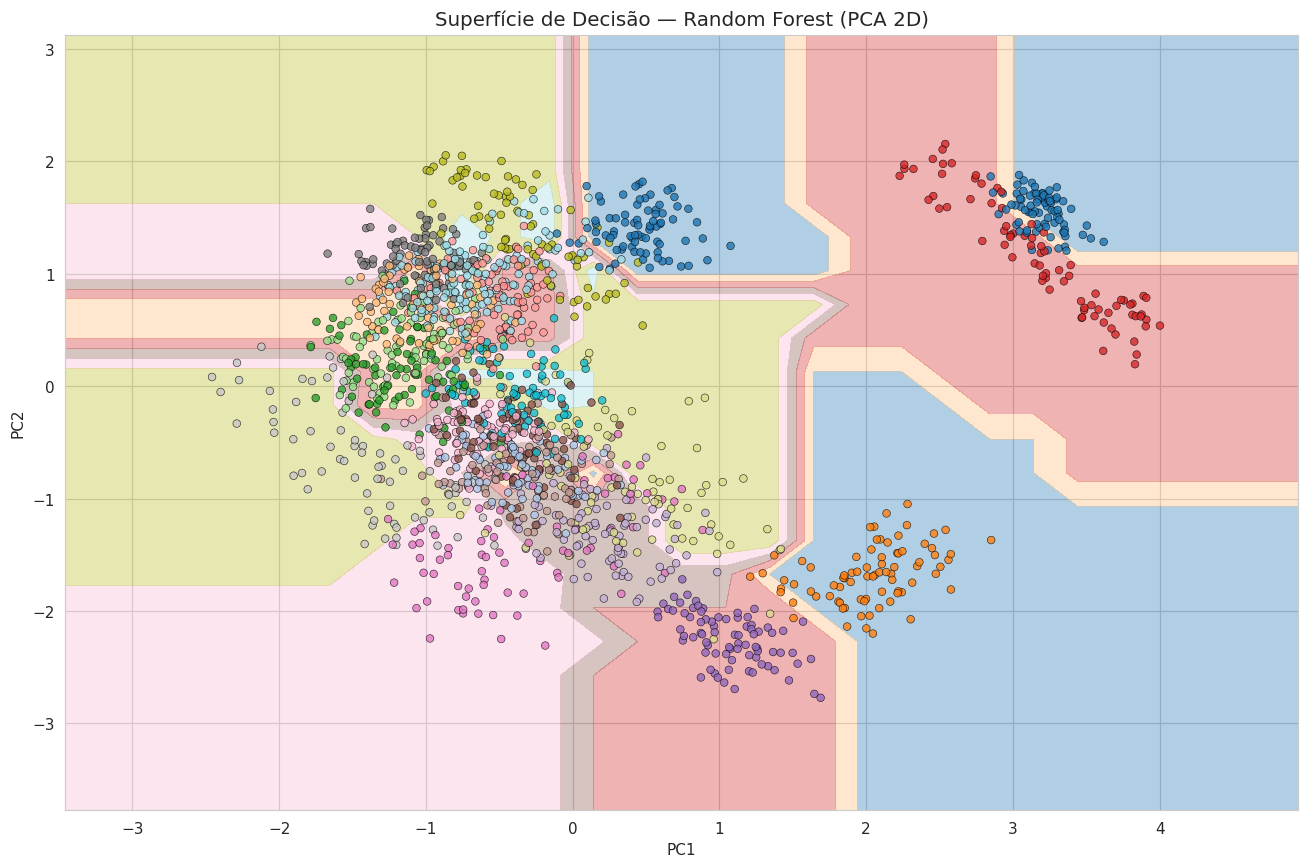

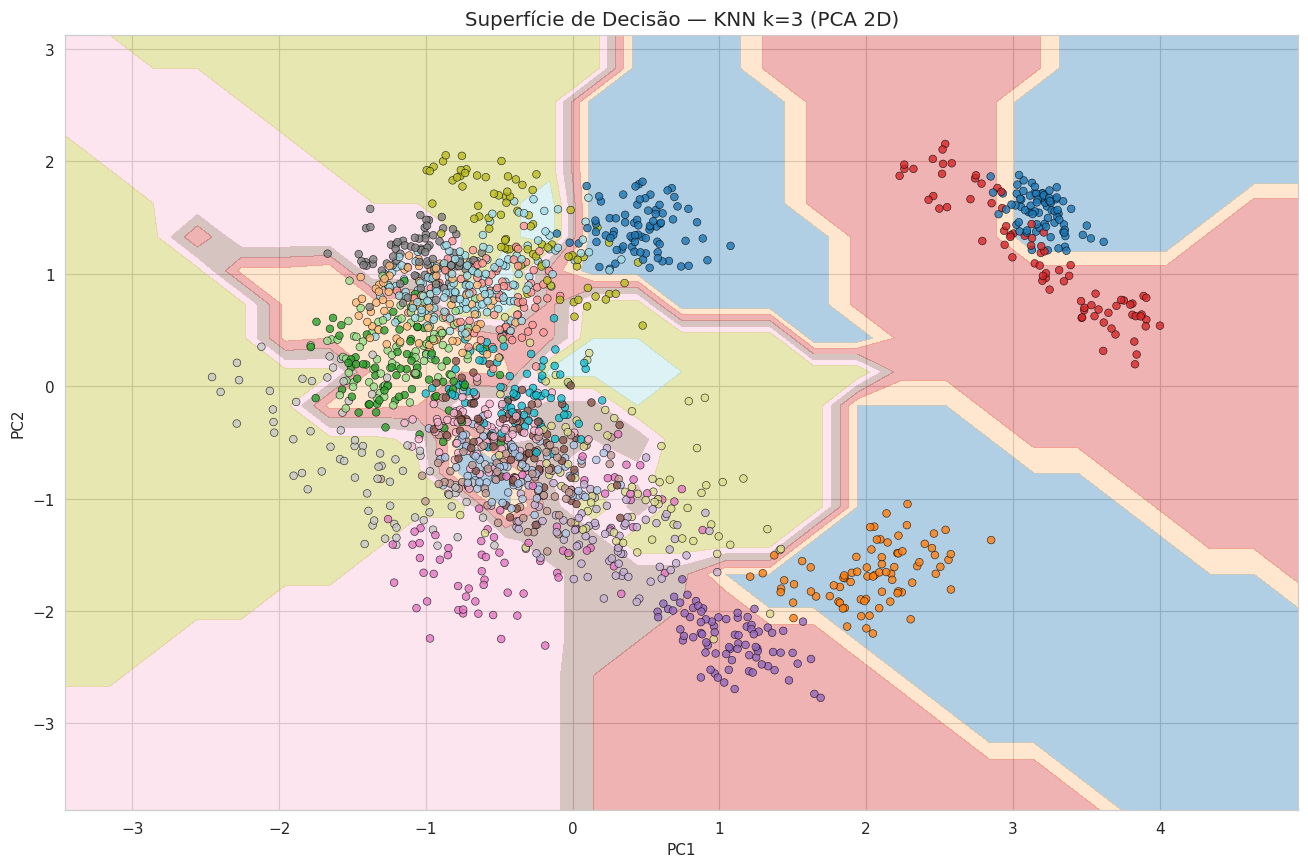

In [ ]:
def plot_decision_surface(clf, X_2d, y, title, fname, h=0.3):
    clf_2d = clf.__class__(**{k: v for k, v in clf.get_params().items()})
    clf_2d.fit(X_2d, y)

    x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
    y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = clf_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    n_classes = len(np.unique(y))
    palette = sns.color_palette('tab20', n_classes)

    fig, ax = plt.subplots(figsize=(12, 8))
    ax.contourf(xx, yy, Z, alpha=0.35, cmap=plt.cm.get_cmap('tab20', n_classes))
    scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y,
                         cmap=plt.cm.get_cmap('tab20', n_classes),
                         edgecolors='k', linewidths=0.4, s=25, alpha=0.8)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_title(title, fontsize=13)
    plt.tight_layout()
    plt.savefig(fname, bbox_inches='tight')
    plt.show()

plot_decision_surface(
    DecisionTreeClassifier(max_depth=8, random_state=42),
    X_train_pca, y_train,
    'Superfície de Decisão — Decision Tree (PCA 2D)',
    'decision_surface_dt.png'
)

plot_decision_surface(
    RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42),
    X_train_pca, y_train,
    'Superfície de Decisão — Random Forest (PCA 2D)',
    'decision_surface_rf.png'
)

plot_decision_surface(
    KNeighborsClassifier(n_neighbors=best_k),
    X_train_pca, y_train,
    f'Superfície de Decisão — KNN k={best_k} (PCA 2D)',
    'decision_surface_knn.png'
)

## 8. Validação Cruzada (5-fold Stratified)

Decision Tree       : 0.8710 ± 0.0254
Random Forest       : 0.9938 ± 0.0055
KNN (k=3)           : 0.9739 ± 0.0073


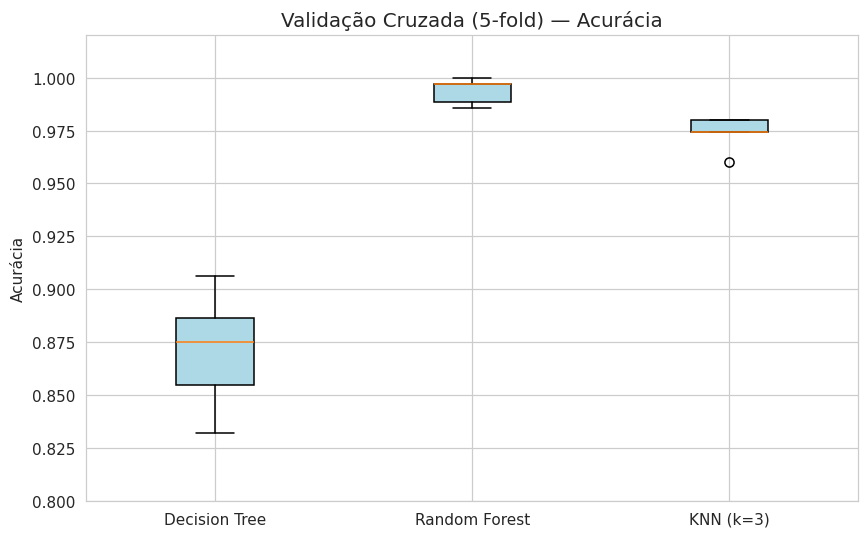

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
models = {
    'Decision Tree': DecisionTreeClassifier(max_depth=8, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
    f'KNN (k={best_k})': KNeighborsClassifier(n_neighbors=best_k),
}

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train_sc, y_train, cv=skf, scoring='accuracy')
    cv_results[name] = scores
    print(f'{name:20s}: {scores.mean():.4f} ± {scores.std():.4f}')

# Boxplot dos scores
plt.figure(figsize=(8, 5))
plt.boxplot(cv_results.values(), labels=cv_results.keys(), patch_artist=True,
            boxprops=dict(facecolor='lightblue'))
plt.title('Validação Cruzada (5-fold) — Acurácia', fontsize=13)
plt.ylabel('Acurácia')
plt.ylim(0.8, 1.02)
plt.tight_layout()
plt.savefig('cross_validation.png', bbox_inches='tight')
plt.show()

## 9. Discussão e Conclusões

### Principais Insights

**Sobre o dataset:**
- O dataset é balanceado: exatamente **100 amostras por cultura** (22 culturas × 100 = 2 200 registros), o que elimina viés de classe.
- Não há valores ausentes, facilitando o pré-processamento.
- A análise de correlação mostra que **N, P e K** apresentam correlações moderadas entre si, enquanto **rainfall** e **humidity** são mais independentes.

**Sobre os modelos:**
- **Random Forest** obteve a maior acurácia e F1, beneficiando-se do ensemble de múltiplas árvores que reduz overfitting.
- **Decision Tree** (max_depth=8) entregou resultado competitivo e oferece maior interpretabilidade.
- **KNN** também obteve boa performance após escalonamento, confirmando que a padronização dos atributos é fundamental para algoritmos baseados em distância.

**Importância dos atributos (Random Forest):**
- Os atributos mais discriminativos tendem a ser **rainfall**, **humidity** e **K** (potássio), sugerindo que condições climáticas e disponibilidade de potássio são determinantes na escolha da cultura.

**Limitações:**
- A superfície de decisão via PCA captura apenas a variância das 2 primeiras componentes; parte da discriminabilidade se perde na redução dimensional.
- O dataset é sintético/controlado; em dados reais, espera-se maior sobreposição entre classes.

In [ ]:
from google.colab import files
files.download('decision_surface_rf.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download('Crop_recommendation.csv')

FileNotFoundError: Cannot find file: Crop_recommendation.csv